# Zeichensprachengesten mit SVMs

In dieser Übung nehmen wir den gleichen Datensatz wie in Übung Nummer 6. Nur diesmal wollen wir die Vorhersagen mit einer SVM ([sklearn.svm.SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)) machen.
Zum Feintuning können wir den Kernel modifizieren, den Regularisierungsparamter `C` einstellen und die Parameter vom Kernel (z.B. `gamma`) einstellen. Ausserdem können wir wieder unsere Inputs skalieren und modifizieren. Vor allem bei der Größe macht es Sinn, diese möglichst klein zu halten, damit die Performance nicht in den Keller geht.

Versuchen Sie, auf eine Accuracy vom mindestens 83% auf dem Testset zu kommen.

In [2]:
import glob
import cv2
import numpy as np

X = []
Y = []
for target in range(10):
    for filename in glob.glob(f"Dataset/{target}/*.JPG"):
        im = cv2.imread(filename)
        
        if im.shape != (100, 100, 3):
            im = cv2.resize(im, (100, 100))
        X.append(im)
        Y.append(target)
        
X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(2062, 100, 100, 3)
(2062,)


0


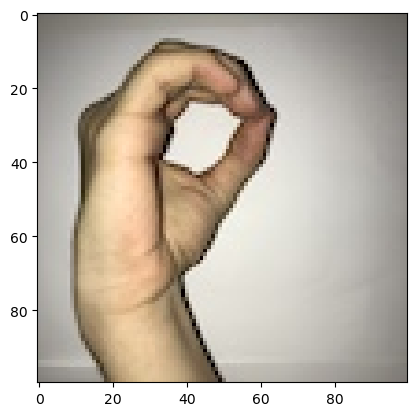

In [3]:
import matplotlib.pyplot as plt

print(Y[0])
plt.imshow(cv2.cvtColor(X[0], cv2.COLOR_BGR2RGB))

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=1)

In [5]:
# ADD CODE HERE
def transform_data(X, grayscale, im_size):
    
    X_transformed = []
    
    for image_idx in range(len(X)):
        img = cv2.resize(X[image_idx], (im_size,im_size))
        if grayscale:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        X_transformed.append(img)
    
    X_transformed = np.array(X_transformed)
    X_transformed = X_transformed.reshape(len(X_transformed), -1) #-1 berechnet length des eintrages automatisch
    return X_transformed/255

## Zunächst ist es nötig eine optimale minimale Größe von Bildern zu finden. Dafür nehmen wir C=1, Gamma = "scale"

Als baseline nutzen wir Radial Base Function, weil dieses Kernel sehr flexibel ist.

Gamma parameter definiert ein Radius der Erkennung von Nachbarn. Wenn Gamma gering ist, werden auch weit entfernte Punkte als "ähnlich" definiert. Bei einem großen Gamma, umgekehrt.

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

img_sz = [16, 32, 64]
grayscale = [True, False]

with open("optimal_image_params.csv", "w") as f:
    f.write("image_size,grayscale,C,score\n")
    for image_size in img_sz:
        for gray in grayscale:
            X_transformed = transform_data(X, gray, image_size)

            #without regularization
            model = SVC(C=1, kernel='rbf', gamma= 'scale')
            scores = cross_val_score(model, X_transformed, Y, cv = 5)

            row = f"{image_size},{gray},None,{np.mean(scores)}\n"
            f.write(row)
            f.flush()
            print(row)


16,True,None,0.7929147370648111

16,False,None,0.8030971579021603

32,True,None,0.8258868332588918

32,False,None,0.8302522391217471

64,True,None,0.8346164695926092

64,False,None,0.8414067091374973



Unterschied im Cross-Validation-Score ohne Grayscale zwischen Größe 32x32 und 64x64 beträgt ≈ nur 1%, da Trainingszeit bei der Nutzung von 64 Größe rasant steigt, nehme 32

## Als nächstes suche nach einem optimalen Kernel

TODO: die kernels beschreiben

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

kernels = ["linear", "poly", "rbf", "sigmoid"]
optimal_data_transformation = transform_data(X, False, 32)

for kernel in kernels:
    model = SVC(C=1, kernel = kernel)
    scores = cross_val_score(model, optimal_data_transformation, Y, cv = 5)
    row = f"Kernel:{kernel}{np.mean(scores)}\n"
    print(row)



Kernel:linear0.8224970027504173

Kernel:poly0.8244281717952937

Kernel:rbf0.8302522391217471

Kernel:sigmoid0.09990361785655516



Optimum - rbf

## Suche nach optimalem C und Gamma für RBF-Kernel

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

c = [0.125, 0.25, 0.5, 1.0, 1.5]
gamma = [1e-4, 1e-3, 1e-2, 1e-1, 1]

with open("optimal_rbf_params.csv", "w") as f:
    f.write("C,gamma,score\n")
    for c_value in c:
        for gamma_value in gamma:
            model = SVC(C = c_value, kernel = "rbf", gamma = gamma_value)
            scores = cross_val_score(model, optimal_data_transformation, Y, cv = 5)
            row = f"{c_value},{gamma_value},{np.mean(scores)}\n"
            f.write(row)
            f.flush()
            print(row)


0.125,0.0001,0.1682503114788782

0.125,0.001,0.18182726439267496

0.125,0.01,0.6406238980700064

0.125,0.1,0.13965537506758502

0.125,1,0.10087214085897647

0.25,0.0001,0.1682503114788782

0.25,0.001,0.4141575965584522

0.25,0.01,0.7317873010649052

0.25,0.1,0.13965537506758502

0.25,1,0.10087214085897647

0.5,0.0001,0.1682503114788782

0.5,0.001,0.6091034109875643

0.5,0.01,0.7875725804555819

0.5,0.1,0.14353416864524318

0.5,1,0.10087214085897647

1.0,0.0001,0.16921883448129948

1.0,0.001,0.7002679893744566

1.0,0.01,0.8229753872916618

1.0,0.1,0.6343343755142341

1.0,1,0.1023272761465949

1.5,0.0001,0.25847105009520677

1.5,0.001,0.7317943534168645

1.5,0.01,0.8457709396083594

1.5,0.1,0.6517948235736618

1.5,1,0.10571945743905593



In [13]:
import pandas as pd
#optimum
results = pd.read_csv("optimal_rbf_params.csv")
#results.head()

max_row_id = results["score"].idxmax()
max_row = results.loc[max_row_id] #[[]] wir erhalten so ein df und kein series
print(max_row)

C        1.500000
gamma    0.010000
score    0.845771
Name: 22, dtype: float64


prüfe ob mit einem größeren c weiter verbessert werden kann


In [15]:
c = [5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]

for c_value in c:
    model = SVC(C = c_value, kernel = "rbf", gamma = 1e-2)
    scores = cross_val_score(model, optimal_data_transformation, Y, cv = 5)
    row = f"{c_value},{gamma_value},{np.mean(scores)}\n"
    print(row)

5,1,0.8714685347563412

5.5,1,0.872924845435953

6,1,0.872924845435953

6.5,1,0.8724394085427489

7,1,0.8729224946519665

7.5,1,0.8724370577587626

8,1,0.871952796257552

8.5,1,0.8724370577587626

9,1,0.8724370577587626

9.5,1,0.8724370577587626

10,1,0.8719516208655588



C = 5.5 ist optimum

## Jetzt ein finales Klassifier

In [16]:
from sklearn.metrics import accuracy_score

X_transformed_train = transform_data(X_train, False, 32)
X_transformed_test = transform_data(X_test, False, 32)

final_model = SVC(C=5.5, kernel = "rbf", gamma=1e-2)
print("training started")
final_model.fit(X_transformed_train, Y_train)

print("making predictions")
preds_test = final_model.predict(X_transformed_test)
preds_train = final_model.predict(X_transformed_train)


print("predictions done")

print("calculating metrics")
train_acc = accuracy_score(Y_train, preds_train)
test_acc = accuracy_score(Y_test, preds_test)

print(f"Train Accuracy: {train_acc} \nTest Accuracy: {test_acc}\n")



training started
making predictions
predictions done
calculating metrics
Train Accuracy: 1.0 
Test Accuracy: 0.8886198547215496



Geben Sie die Confusion Matrix aus.
Plotten Sie einige der falschen Vorhersagen, um eine Idee zu bekommen, wo der Classifier Fehler macht.
Was könnten wir eventuell tun, um an bessere Ergebnisse zu kommen?

In [17]:
# ADD CODE HERE

from sklearn.metrics import confusion_matrix
print("Confusion Matrix for test data")
c_matrix_test = confusion_matrix(Y_test, preds_test)
print(c_matrix_test)

Confusion Matrix for test data
[[40  0  0  0  0  0  0  0  0  0]
 [ 0 39  1  0  0  0  0  2  2  0]
 [ 0  3 35  0  0  0  0  2  0  0]
 [ 0  2  2 37  0  1  0  0  0  0]
 [ 0  0  0  0 35  1  2  0  2  2]
 [ 0  0  0  0  1 43  0  0  0  0]
 [ 0  0  0  0  5  0 29  1  2  0]
 [ 0  0  3  1  1  0  1 35  1  0]
 [ 0  1  0  0  0  1  1  1 42  1]
 [ 0  1  0  0  2  0  0  0  0 32]]


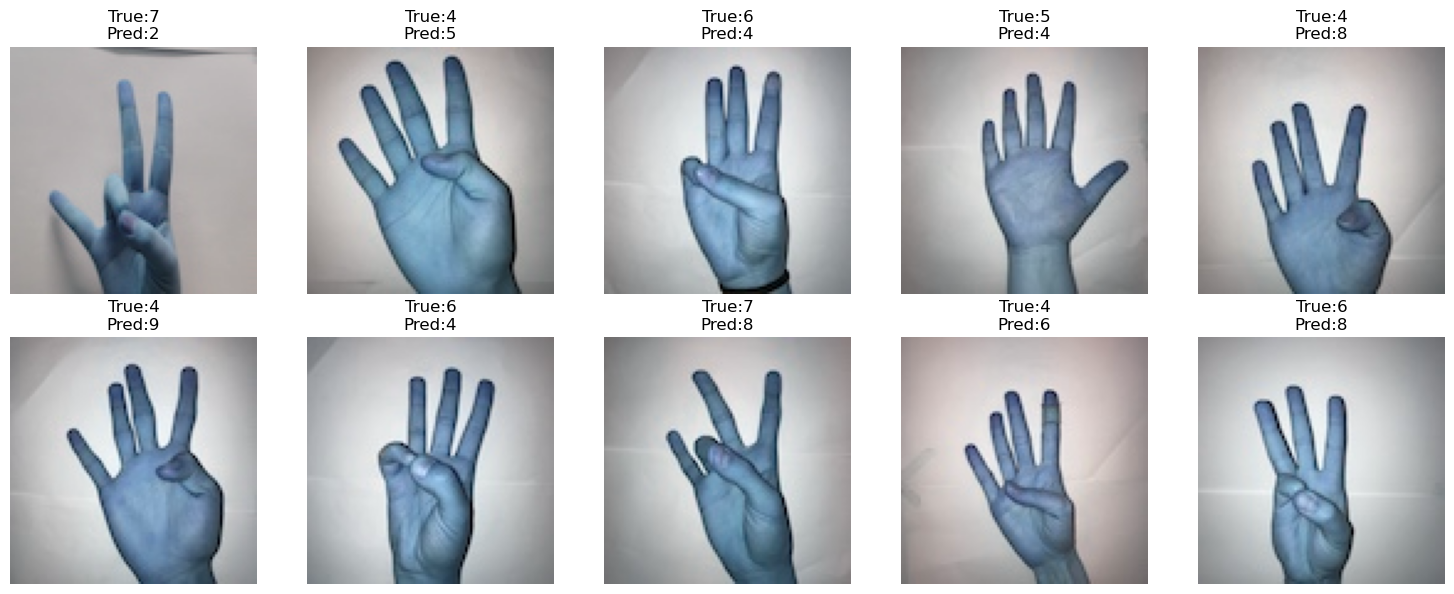

In [41]:
#plotting
wrong_idx = np.where(preds_test != Y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for ax, idx in zip(axes, wrong_idx[:10]):
    ax.set_title(
        f"True:{Y_test[idx]}\nPred:{preds_test[idx]}"
    )

    ax.imshow(X_test[idx])
    ax.axis("off")

plt.tight_layout()
plt.show()
